### BMI585 Project - Kimia Ramezan

# HR (1 Hz) + PTAF-derived Respiration Driver (1 Hz)

This notebook builds two aligned 1 Hz signals from an HSP `.h5` file:

- **HR\_1hz**: heart rate at 1 Hz (bpm), made continuous by filling invalid values.
- **Resp\_1hz**: a respiration “driver” derived from **PTAF**, using:
  1) robust clipping (MAD),
  2) bandpass filtering in the breathing range (0.1–0.6 Hz),
  3) per-second aggregation (energy or mean),
  4) z-scoring and optional smoothing.

These outputs can feed:
- **Model A**: `y_k = HR_1hz`
- **Model B**: `y_k = HR_1hz`, `u_k = Resp_1hz`


In [13]:
import os, glob, h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mne.filter import filter_data, notch_filter
from config import *  # expects ORIGINAL_SAMPLE_RATE, NOTCH_FREQ_US, ...


## 1) Load prepared H5 data

The H5 format stores signals under groups. Each dataset is expected to have shape `(T, 1)`.
We load only the requested signals (`hr`, `ptaf`) into a pandas DataFrame.

In [14]:
def load_prepared_data(file_path: str, get_signals=None):
    if get_signals is None:
        get_signals = []
    Xy = pd.DataFrame([])
    with h5py.File(file_path, "r") as f:
        for group_name in f.keys():
            group = f[group_name]
            dataset_names = list(group.keys())

            use_names = dataset_names if len(get_signals) == 0 else [
                c for c in dataset_names if c in get_signals
            ]

            for dataset_name in use_names:
                dataset = group[dataset_name][:]
                assert dataset.shape[1] == 1
                Xy[dataset_name] = dataset.flatten()

        params = {k: f.attrs[k] for k in f.attrs.keys()}
    return Xy, params

## 2) Choose a valid HR window

We find the first time index where HR stays within a valid range `[lo, hi]`
for `min_run_sec` seconds. This avoids starting in a corrupted/noisy segment.

In [15]:
def find_first_valid_hr_index(hr, fs, lo=30, hi=220, min_run_sec=3):
    hr = hr.astype(float)
    valid = (hr >= lo) & (hr <= hi)
    run = int(min_run_sec * fs)

    if run <= 1:
        idxs = np.where(valid)[0]
        return int(idxs[0]) if len(idxs) else None

    v = valid.astype(np.int8)
    s = np.convolve(v, np.ones(run, dtype=np.int32), mode="valid")
    hits = np.where(s == run)[0]
    return int(hits[0]) if len(hits) else None


## 3) HR preprocessing and downsampling to 1 Hz

1. Replace invalid HR values with NaN.
2. Forward-fill then back-fill to make HR continuous.
3. Downsample by taking mean over 1-second blocks.

In [16]:
def make_hr_continuous(hr, lo=30, hi=220):
    hr = hr.astype(float).copy()
    hr[(hr < lo) | (hr > hi)] = np.nan
    return pd.Series(hr).ffill().bfill().values


def downsample_mean(x, fs, target_hz=1):
    x = np.asarray(x, dtype=float)
    block = int(fs / target_hz)
    if block <= 1:
        return x
    n = (len(x) // block) * block
    if n == 0:
        return np.array([])
    return x[:n].reshape(-1, block).mean(axis=1)


## 4) PTAF → respiration driver at 1 Hz

We build a 1 Hz driver that captures breathing-related dynamics:

- Robust spike clipping with MAD (reduces artifacts)
- Optional notch filter
- Bandpass filter in breathing band (0.1–0.6 Hz)
- Aggregate per second:
  - `energy=True` → mean squared value per second (often more stable)
  - `energy=False` → mean per second
- Z-score so it has consistent scale for modeling


In [ ]:
import numpy as np
import pandas as pd
from mne.filter import filter_data, notch_filter

def resp_breathing_1hz(
    ptaf,
    fs,
    f_lo=0.1,
    f_hi=0.6,
    clip_z_raw=6.0,
    do_notch=False,
    feature="rms",         
    smooth_sec=20,          
    standardize="robust",   # "robust" or "zscore"
    winsor_q=(0.01, 0.99),  # clip feature by quantiles before z
    clip_z_out=4.0,
    eps=1e-8,
):
    x = np.asarray(ptaf, float)

    #robust clip RAW (MAD)
    med = np.median(x)
    mad = np.median(np.abs(x - med)) + eps
    xz = (x - med) / (1.4826 * mad)
    xz = np.clip(xz, -clip_z_raw, clip_z_raw)
    x = med + xz * (1.4826 * mad)

    if do_notch:
        x = notch_filter(x, fs, NOTCH_FREQ_US, verbose=False)

    #breathing band
    x = filter_data(x, fs, f_lo, f_hi, verbose=False)

    #1 Hz blocks
    block = int(round(fs))
    n = (len(x) // block) * block
    if n <= 0:
        return np.array([])
    X = x[:n].reshape(-1, block)

    #per-second amplitude feature (more stable than raw mean)
    rms = np.sqrt(np.mean(X**2, axis=1) + eps)
    r = np.log(rms + 1e-6) if feature == "log_rms" else rms

    # smooth FIRST
    if smooth_sec and smooth_sec > 1:
        r = pd.Series(r).rolling(int(smooth_sec), center=True, min_periods=1).mean().values

    #winsorize feature BEFORE standardizing (kills burst-driven jitter)
    lo, hi = np.quantile(r, winsor_q[0]), np.quantile(r, winsor_q[1])
    r = np.clip(r, lo, hi)

    #standardize
    if standardize == "robust":
        med = np.median(r)
        mad = np.median(np.abs(r - med)) + eps
        z = (r - med) / (1.4826 * mad)
    else:
        z = (r - r.mean()) / (r.std() + eps)

    #final clip
    z = np.clip(z, -clip_z_out, clip_z_out)
    z = z - np.mean(z)
    return z


## 5) Plot HR (1 Hz) and Resp driver (1 Hz)

We plot HR and respiration driver on two y-axes for easy visual inspection.

In [ ]:
def plot_raw_vs_processed(
    hr_raw, ptaf_raw, fs,
    hr_1hz, resp_1hz,
    title="Raw vs processed",
    resp_name="PTAF-derived resp driver",
):

    hr_raw = np.asarray(hr_raw, float)
    ptaf_raw = np.asarray(ptaf_raw, float)
    N = min(len(hr_raw), len(ptaf_raw))
    hr_raw = hr_raw[:N]
    ptaf_raw = ptaf_raw[:N]
    t_raw = np.arange(N) / float(fs)

    hr_1hz = np.asarray(hr_1hz, float)
    resp_1hz = np.asarray(resp_1hz, float)  
    T = min(len(hr_1hz), len(resp_1hz))      
    hr_1hz = hr_1hz[:T]
    resp_1hz = resp_1hz[:T]          
    t_1hz = np.arange(T)

    fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex="col", constrained_layout=True)
    (ax11, ax12), (ax21, ax22) = axes

    ax11.plot(t_raw, hr_raw, linewidth=1.2, label="HR (raw)")
    ax11.set_title("Raw")
    ax11.set_ylabel("HR (bpm)")
    ax11.grid(True, alpha=0.3)
    ax11.legend(loc="upper right")

    ax12.plot(t_1hz, hr_1hz, linewidth=1.6, label="HR (1 Hz)")
    ax12.set_title("Processed (1 Hz)")
    ax12.set_ylabel("HR (bpm)")
    ax12.grid(True, alpha=0.3)
    ax12.legend(loc="upper right")

    ax21.plot(t_raw, ptaf_raw, linewidth=1.0, label="PTAF (raw)")
    ax21.set_xlabel("Time (s)")
    ax21.set_ylabel("PTAF (raw)")
    ax21.grid(True, alpha=0.3)
    ax21.legend(loc="upper right")

    ax22.plot(t_1hz, resp_1hz, linewidth=1.4, label=f"{resp_name} (z)")  # <-- FIX
    ax22.axhline(0, linestyle="--", linewidth=1, alpha=0.6)
    ax22.set_xlabel("Time (s) @ 1 Hz")
    ax22.set_ylabel("Resp driver (z)")
    ax22.grid(True, alpha=0.3)
    ax22.legend(loc="upper right")

    fig.suptitle(title, y=1.02)
    plt.show()


## 6) End-to-end runner

This function:
1) Finds one `.h5` file from a cohort folder,
2) selects a valid HR window,
3) computes `hr_1hz` and `resp_1hz`,
4) aligns lengths,
5) plots the result,
6) returns `(hr_1hz, resp_1hz)`.


In [ ]:
def build_hr_and_resp_1hz(
    root_dir="/opt/scratchspace/qli50/HSP",
    cohort="I0004",
    file_index=0,
    minutes=30,
    resp_col="ptaf",
    hr_lo=30,
    hr_hi=220,
    breathing_band=(0.1, 0.6),
    resp_clip_z=6.0,
    resp_do_notch=False,
    resp_energy=True,
    resp_smooth_sec=5,
):
    files = sorted(glob.glob(os.path.join(root_dir, cohort, "*.h5")))
    if not files:
        raise FileNotFoundError(f"No .h5 files found for cohort={cohort} under {root_dir}")
    if file_index >= len(files):
        raise IndexError(f"file_index={file_index} out of range (n_files={len(files)})")

    path = files[file_index]
    Xy, params = load_prepared_data(path, get_signals=["hr", resp_col])
    fs = float(params.get("fs", ORIGINAL_SAMPLE_RATE))

    print("Using file:", path)
    print("fs:", fs)
    print("Columns loaded:", list(Xy.columns))

    hr_full = Xy["hr"].values.astype(float)
    start_idx = find_first_valid_hr_index(hr_full, fs, lo=hr_lo, hi=hr_hi, min_run_sec=3)
    if start_idx is None:
        raise RuntimeError("No sustained valid HR segment found in this file.")

    start = max(0, start_idx - int(10 * fs))  # 10s context
    nwin = int(minutes * 60 * fs)
    end = min(len(Xy), start + nwin)

    print(f"Window: start={start/fs:.1f}s  end={end/fs:.1f}s  ({(end-start)/fs/60:.1f} min)")

    hr = Xy["hr"].values[start:end].astype(float)
    resp = Xy[resp_col].values[start:end].astype(float)

    # HR -> 1 Hz
    hr_cont = make_hr_continuous(hr, lo=hr_lo, hi=hr_hi)
    hr_1hz = downsample_mean(hr_cont, fs, target_hz=1)

    # Resp -> 1 Hz (already standardized + smoothed inside)
    f_lo, f_hi = breathing_band
    resp_1hz = resp_breathing_1hz(
        resp, fs,
        f_lo=0.1, f_hi=0.6,
        feature="rms",      
        smooth_sec=20,     
        winsor_q=(0.01, 0.99),
        clip_z_out=3.0,
    )

    print("resp_1hz mean/std:", float(resp_1hz.mean()), float(resp_1hz.std()))
    print("fraction clipped at +3:", float(np.mean(resp_1hz >= 2.999)))
    print("fraction clipped at -3:", float(np.mean(resp_1hz <= -2.999)))


    # resp_1hz = np.clip(resp_1hz, -3, 3)


    # light clipping + smoothing (optional)
    # resp_1hz = np.clip(resp_1hz, -3, 3)
    # if resp_smooth_sec and resp_smooth_sec > 1:
    #     resp_1hz = pd.Series(resp_1hz).rolling(int(resp_smooth_sec), center=True, min_periods=1).mean().values

    T = min(len(hr_1hz), len(resp_1hz))
    hr_1hz, resp_1hz = hr_1hz[:T], resp_1hz[:T]
    print("hr_1hz shape:", hr_1hz.shape, "resp_1hz shape:", resp_1hz.shape)

    plot_raw_vs_processed(
    hr_raw=hr, ptaf_raw=resp, fs=fs,
    hr_1hz=hr_1hz, resp_1hz=resp_1hz,
    title=f"{cohort} / {os.path.basename(path)}"
    )

    return hr_1hz, resp_1hz


Using file: /opt/scratchspace/qli50/HSP/I0004/sub-I0004177500001_ses-1.h5
fs: 200.0
Columns loaded: ['hr', 'ptaf']
Window: start=2699.7s  end=4499.6s  (30.0 min)
resp_1hz mean/std: 6.315935428978668e-17 1.3219896789441432
fraction clipped at +3: 0.0
fraction clipped at -3: 0.0
hr_1hz shape: (1800,) resp_1hz shape: (1800,)


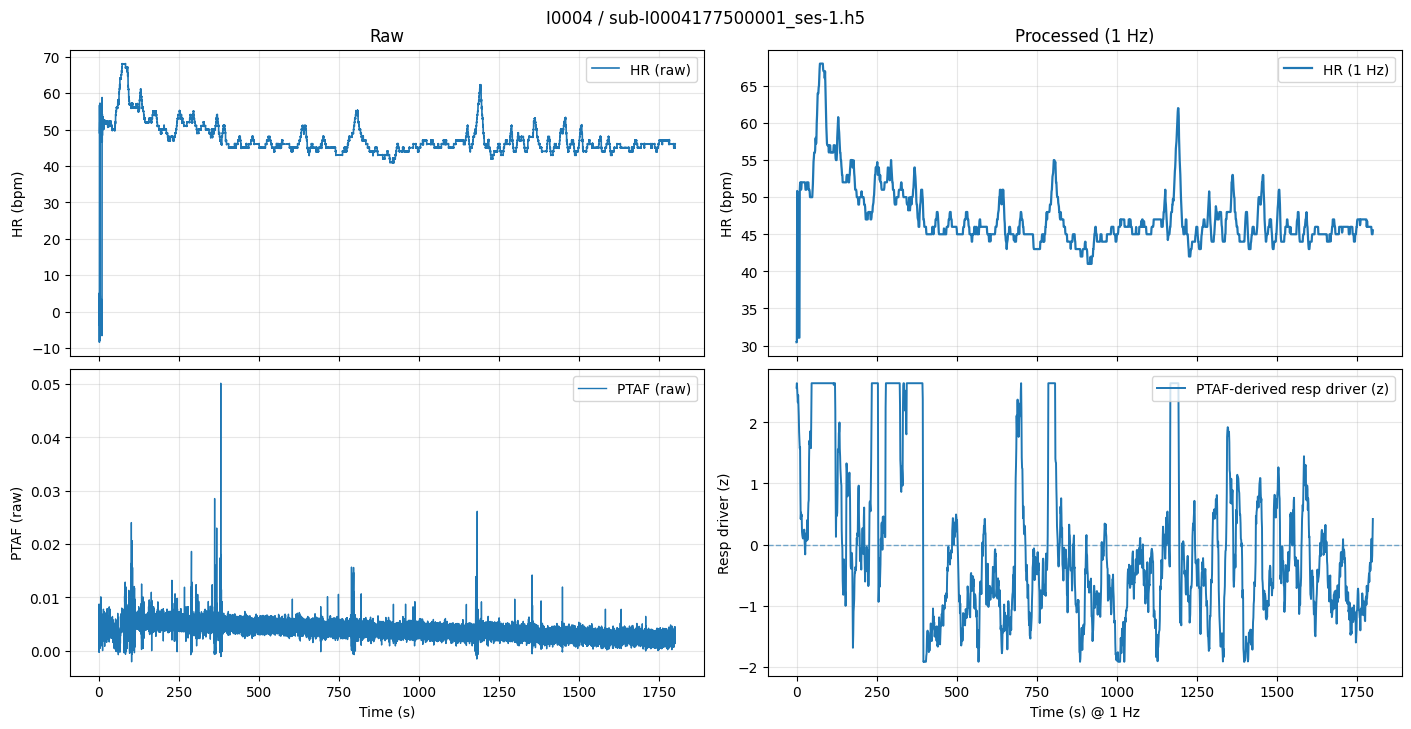

In [20]:
hr_1hz, resp_1hz = build_hr_and_resp_1hz(
    cohort="I0004",
    file_index=0,
    minutes=30,
    resp_col="ptaf",
    resp_energy=True,
    resp_smooth_sec=30,
)


# Kalman filtering on HR (1 Hz): Model A vs Model B

We compare two 1D state-space models on the same HR time series `y_k` (sampled at 1 Hz):

Both models are evaluated using:
- **one-step prediction RMSE**: compare `y[k]` vs `x_{k|k-1}`  
- **filtered RMSE**: compare `y[k]` vs `x_{k|k}`  
- **innovation diagnostics**: `e_k = y_k - x_{k|k-1}`


In [21]:
import numpy as np
import matplotlib.pyplot as plt

def rmse(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    T = min(len(x), len(y))
    return float(np.sqrt(np.mean((x[:T] - y[:T])**2)))

def estimate_a_ar1(y, a_min=0.90, a_max=0.9995):
    """Least-squares AR(1): y[k] ≈ a*y[k-1]."""
    y = np.asarray(y, float)
    y0, y1 = y[:-1], y[1:]
    denom = np.dot(y0, y0) + 1e-12
    a_hat = np.dot(y1, y0) / denom
    return float(np.clip(a_hat, a_min, a_max))

def shift_with_hold(u, lag):
    """Shift u forward by lag seconds (u affects y later). Hold-fill start."""
    u = np.asarray(u, float).copy()
    if lag <= 0:
        return u
    u2 = np.roll(u, lag)
    u2[:lag] = u2[lag]
    return u2

def plot_innovation(e, burn=30, title="Innovation e_k"):
    e = np.asarray(e, float)
    sigma = np.std(e[burn:]) if len(e) > burn else np.std(e)

    plt.figure(figsize=(12, 3.2))
    plt.plot(np.arange(len(e)), e, linewidth=1.2, label="e_k = y_k - x_{k|k-1}")
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.axhline(+3*sigma, linestyle="--", linewidth=1, label="±3σ")
    plt.axhline(-3*sigma, linestyle="--", linewidth=1)
    plt.xlabel("Time (s) @ 1 Hz")
    plt.ylabel("Innovation")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.title(title)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 3.2))
    plt.hist(e[burn:], bins=60)
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.xlabel("Innovation")
    plt.ylabel("Count")
    plt.title("Innovation histogram (after burn-in)")
    plt.tight_layout()
    plt.show()


## Model A: AR(1) Kalman filter (1D)

### What is the state and what do we observe?
- **State**: $x_k$ = the *latent / true* heart rate (HR) at second $k$ (1 Hz).
- **Observation**: $y_k$ = the *measured* HR value you computed from the raw data (also 1 Hz).

We assume measurement noise:
$$
y_k = x_k + v_k,\qquad v_k \sim \mathcal N(0, R)
$$
So $R$ controls how noisy we think the observed HR is.

---

### Why AR(1) dynamics?
We model HR as slowly varying over time:
$$
x_{k+1} = a\,x_k + w_k,\qquad w_k \sim \mathcal N(0, Q)
$$

- $a$ is the AR(1) coefficient (typically very close to $1$ for slow drift).
- $Q$ is the **process noise variance** (how much we allow HR to change from one second to the next).

---

### Connection to the continuous-time model you mentioned
If you start from:
$$
\frac{dx}{dt} = \alpha x(t) + w(t)
$$
and discretize with step $\Delta t$ (Euler):
$$
x_{k+1} \approx x_k + \Delta t\,\alpha x_k + w_k
= (1+\alpha\Delta t)\,x_k + w_k
$$
So in your discrete model:
$$
a = 1+\alpha\Delta t
$$
Since you are working at **1 Hz**, $\Delta t = 1$, so:
$$
a = 1+\alpha
$$
That’s exactly why your code uses `a = 1 + alpha`.

---

### What the Kalman filter is doing here
At each second $k$:

**Predict (prior):**
$$
\hat x_{k|k-1} = a\,\hat x_{k-1|k-1}
$$
$$
P_{k|k-1} = a^2 P_{k-1|k-1} + Q
$$

**Update (posterior using observation $y_k$):**
Innovation:
$$
e_k = y_k - \hat x_{k|k-1}
$$
Kalman gain:
$$
K_k = \frac{P_{k|k-1}}{P_{k|k-1}+R}
$$
State update:
$$
\hat x_{k|k} = \hat x_{k|k-1} + K_k e_k
$$
Covariance update:
$$
P_{k|k} = (1-K_k)P_{k|k-1}
$$

**Interpretation**: if $R$ is large (noisy measurements), the filter trusts the model more; if $Q$ is large (model is uncertain), it trusts measurements more.

### How parameters are chosen (grid search)
We run a small grid search over $(a,Q,R)$ and pick the set that minimizes the **one-step prediction RMSE** between $y_k$ and $\hat x_{k|k-1}$.


In [22]:
def kalman_ar1(y, a, Q, R, x0=None, P0=10.0):
    y = np.asarray(y, float)
    T = len(y)
    if T == 0:
        raise ValueError("Input y is empty.")
    if x0 is None:
        x0 = y[0]

    x_f = np.zeros(T)  # filtered x_{k|k}
    x_p = np.zeros(T)  # predicted x_{k|k-1}
    P_f = np.zeros(T)
    P_p = np.zeros(T)
    K   = np.zeros(T)
    e   = np.zeros(T)

    x_f[0] = x0
    P_f[0] = float(P0)
    x_p[0] = x0
    P_p[0] = float(P0)
    e[0]   = y[0] - x_p[0]

    for k in range(1, T):
        # predict
        x_p[k] = a * x_f[k-1]
        P_p[k] = a * P_f[k-1] * a + Q

        # update
        e[k] = y[k] - x_p[k]
        S = P_p[k] + R
        K[k] = P_p[k] / S
        x_f[k] = x_p[k] + K[k] * e[k]
        P_f[k] = (1.0 - K[k]) * P_p[k]

    return x_f, x_p, e, K, P_f, P_p

def tune_modelA_ar1(y):
    y = np.asarray(y, float)
    y_var = np.var(y) + 1e-12

    a_hat = estimate_a_ar1(y)
    a_grid = np.unique(np.clip(
        np.concatenate([
            np.linspace(0.95, 0.9995, 10),
            np.array([a_hat-0.01, a_hat-0.005, a_hat, a_hat+0.005, a_hat+0.01]),
            np.array([0.995, 0.998, 0.999, 0.9995]),
        ]),
        0.90, 0.9995
    ))

    R_grid = y_var * np.array([0.05, 0.1, 0.2, 0.5, 1.0, 2.0])
    Q_grid = y_var * np.array([1e-4, 5e-4, 1e-3, 5e-3, 1e-2])

    best = None
    for a in a_grid:
        for R in R_grid:
            for Q in Q_grid:
                x_f, x_p, e, *_ = kalman_ar1(y, a=a, Q=Q, R=R, P0=y_var)
                pred_rmse = rmse(y[1:], x_p[1:])
                if best is None or pred_rmse < best[0]:
                    best = (pred_rmse, {"a": float(a), "alpha": float(a-1.0), "Q": float(Q), "R": float(R)})
    return best

def plot_state_fit(y, x_p, x_f, title="", ylabel="HR (bpm)"):
    T = min(len(y), len(x_p), len(x_f))
    t = np.arange(T)
    plt.figure(figsize=(12, 4))
    plt.plot(t, y[:T],   label="Observed y_k", linewidth=2, alpha=0.85)
    plt.plot(t, x_p[:T], label="Predicted x_{k|k-1}", linewidth=2, alpha=0.85)
    plt.plot(t, x_f[:T], label="Filtered x_{k|k}", linewidth=2, alpha=0.95)
    plt.xlabel("Time (s) @ 1 Hz")
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.title(title)
    plt.tight_layout()
    plt.show()


## Model B: ARX(1) Kalman filter (1D + respiration input)

### What changes compared to Model A?
We still have:
- **State**: $x_k$ (latent HR)
- **Observation**: $y_k$ (measured HR)

But now we add an external input:
- **Input**: $u_k$ = your 1 Hz **respiration driver** derived from PTAF.

Observation equation stays the same:
$$
y_k = x_k + v_k,\qquad v_k \sim \mathcal N(0,R)
$$

---

### State dynamics with input (ARX(1))
We assume respiration can *drive* changes in HR:
$$
x_{k+1} = a\,x_k + b\,u_k + w_k,\qquad w_k \sim \mathcal N(0,Q)
$$

- $a$ = same meaning as before (HR persistence)
- $b$ = strength/sign of respiration influence on HR
- $Q$ = how much unmodeled HR variability remains

---

### Connection to continuous-time form (optional intuition)
If you had:
$$
\frac{dx}{dt} = \alpha x(t) + \beta u(t) + w(t)
$$
Euler discretization gives:
$$
x_{k+1} \approx (1+\alpha\Delta t)x_k + (\beta\Delta t)u_k + w_k
$$
So:
$$
a = 1+\alpha\Delta t,\qquad b = \beta\Delta t
$$
With $\Delta t=1$ (1 Hz):
$$
a = 1+\alpha,\qquad b=\beta
$$

---

### Why do we search over a lag?
Physiologically, respiration often affects HR with a delay (RSA timing + sensor processing).

So instead of using $u_k$ directly, we test:
$$
u^{(\ell)}_k = u_{k-\ell}
$$
for small lags $\ell \in \{0,1,\dots,L\}$.

Then the model becomes:
$$
x_{k+1} = a\,x_k + b\,u^{(\ell)}_k + w_k
$$

In your implementation, predicting $x_k$ uses $u_{k-1}$ (because prediction step moves from $k-1$ to $k$), so with lag it effectively becomes “use respiration from a few seconds earlier”.

---

### Kalman steps (same structure as Model A)
Only the **prediction mean** changes:

**Predict:**
$$
\hat x_{k|k-1} = a\,\hat x_{k-1|k-1} + b\,u_{k-1}^{(\ell)}
$$
$$
P_{k|k-1} = a^2 P_{k-1|k-1} + Q
$$

**Update:** identical equations as Model A using $e_k$, $K_k$, $R$.

---

### How parameters are chosen (grid search)
We run a small grid search over:
$$
(\ell,\;a,\;b,\;Q,\;R)
$$
and pick the set that minimizes **one-step prediction RMSE** between $y_k$ and $\hat x_{k|k-1}$.

### What it means if tuning finds $b \approx 0$
If the best fit returns $b \approx 0$ (as in your screenshot), it usually means **the respiration driver you built (as $u_k$) is not predictive of the next-step HR** under this simple linear model (or the effect is too small relative to noise / wrong lag / wrong feature).


In [23]:
def kalman_arx1(y, u, a, b, Q, R, x0=None, P0=10.0):
    y = np.asarray(y, float)
    u = np.asarray(u, float)
    T = min(len(y), len(u))
    y = y[:T]
    u = u[:T]
    if T == 0:
        raise ValueError("Inputs are empty after alignment.")
    if x0 is None:
        x0 = y[0]

    x_f = np.zeros(T)
    x_p = np.zeros(T)
    P_f = np.zeros(T)
    P_p = np.zeros(T)
    K   = np.zeros(T)
    e   = np.zeros(T)

    x_f[0] = x0
    P_f[0] = float(P0)
    x_p[0] = x0
    P_p[0] = float(P0)
    e[0]   = y[0] - x_p[0]

    for k in range(1, T):
        # predict (u[k-1] drives x at time k)
        x_p[k] = a * x_f[k-1] + b * u[k-1]
        P_p[k] = a * P_f[k-1] * a + Q

        # update
        e[k] = y[k] - x_p[k]
        S = P_p[k] + R
        K[k] = P_p[k] / S
        x_f[k] = x_p[k] + K[k] * e[k]
        P_f[k] = (1.0 - K[k]) * P_p[k]

    return x_f, x_p, e, K, P_f, P_p

def tune_modelB_arx1(y, u, max_lag=10):
    y = np.asarray(y, float)
    u = np.asarray(u, float)
    T = min(len(y), len(u))
    y = y[:T]
    u = u[:T]

    y_var = np.var(y) + 1e-12
    a_hat = estimate_a_ar1(y)

    a_grid = np.unique(np.clip(
        np.array([a_hat - 0.01, a_hat - 0.005, a_hat, a_hat + 0.005, a_hat + 0.01,
                  0.995, 0.998, 0.999, 0.9995]),
        0.90, 0.9995
    ))
    b_grid = np.array([-1.0, -0.5, -0.2, 0.0, 0.2, 0.5, 1.0])
    R_grid = y_var * np.array([0.1, 0.2, 0.5, 1.0])
    Q_grid = y_var * np.array([1e-4, 5e-4, 1e-3, 5e-3])

    best = None
    for lag in range(max_lag + 1):
        u_lag = shift_with_hold(u, lag)
        for a in a_grid:
            for b in b_grid:
                for R in R_grid:
                    for Q in Q_grid:
                        x_f, x_p, e, *_ = kalman_arx1(y, u_lag, a=a, b=b, Q=Q, R=R, P0=y_var)
                        pred_rmse = rmse(y[1:], x_p[1:])
                        if best is None or pred_rmse < best[0]:
                            best = (pred_rmse, {
                                "lag": int(lag), "a": float(a), "alpha": float(a-1.0),
                                "b": float(b), "Q": float(Q), "R": float(R)
                            })
    return best

def plot_modelB_with_input(y, u, x_p, x_f, title="Model B"):
    T = min(len(y), len(u), len(x_p), len(x_f))
    t = np.arange(T)

    fig, ax1 = plt.subplots(figsize=(12, 4))
    ax1.plot(t, y[:T],   label="Observed y_k", linewidth=2, alpha=0.85)
    ax1.plot(t, x_p[:T], label="Predicted x_{k|k-1}", linewidth=2, alpha=0.85)
    ax1.plot(t, x_f[:T], label="Filtered x_{k|k}", linewidth=2, alpha=0.95)
    ax1.set_xlabel("Time (s) @ 1 Hz")
    ax1.set_ylabel("HR (bpm)")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(t, u[:T], label="Resp input u_k", alpha=0.25)
    ax2.set_ylabel("Resp driver (z)")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    plt.title(title)
    plt.tight_layout()
    plt.show()


## Running both models on the same (HR, Resp) data

We run:
- Model A: Kalman AR(1)
- Model B: Kalman ARX(1) with lag search

And then compare RMSEs.


=== Comparison ===
rmse_pred_A : 1.2499502341479178
rmse_filt_A : 0.7713926572009489
rmse_pred_B : 1.587423158550356
rmse_filt_B : 1.2283412785349044
paramsA: {'a': 0.9995, 'Q': 0.1878376141460642, 'R': 0.9391880707303211}
paramsB: {'lag': 0, 'a': 0.9995, 'b': 0.0, 'Q': 0.0939188070730321, 'R': 1.8783761414606421}


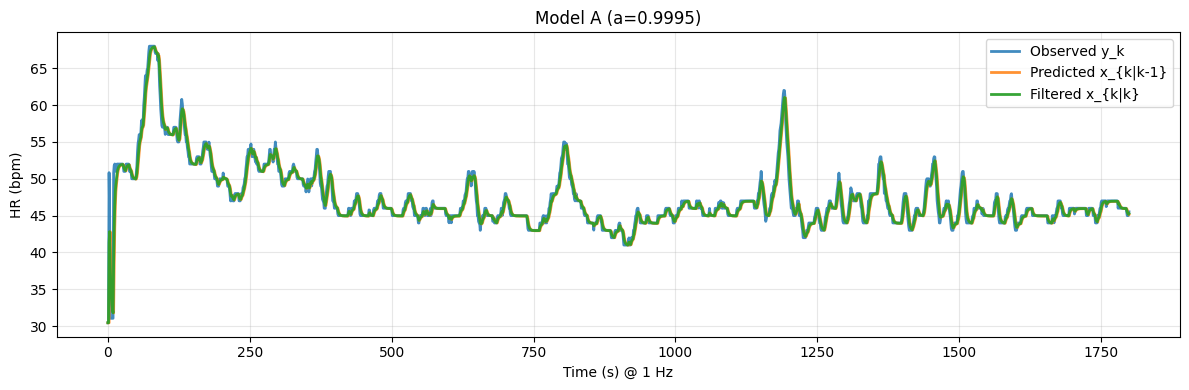

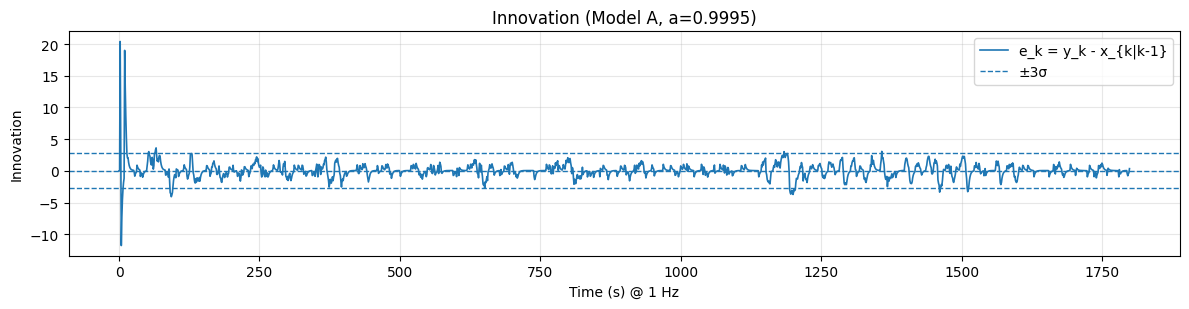

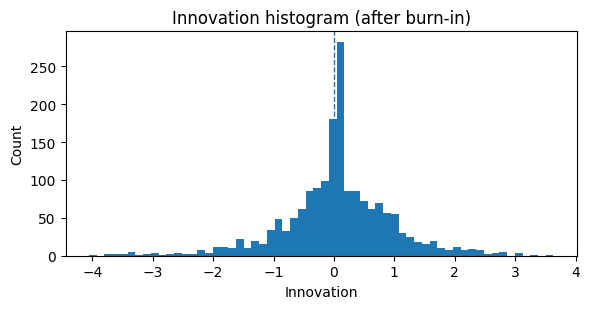

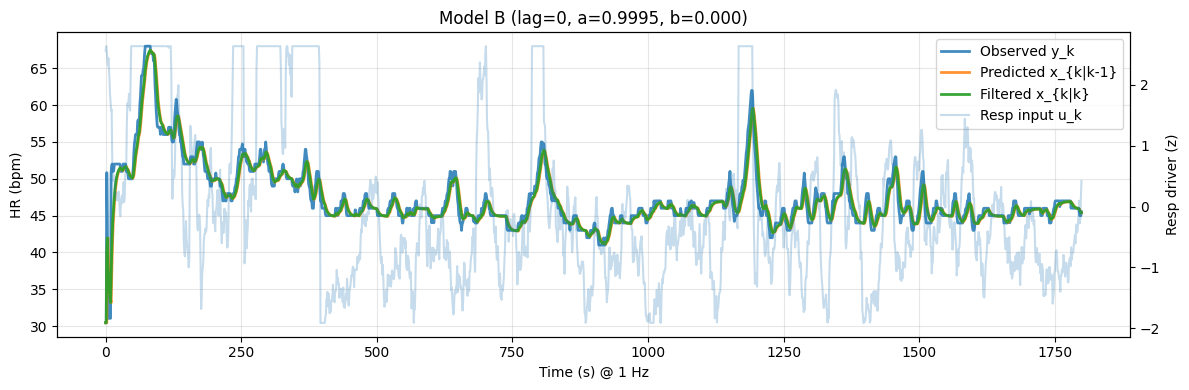

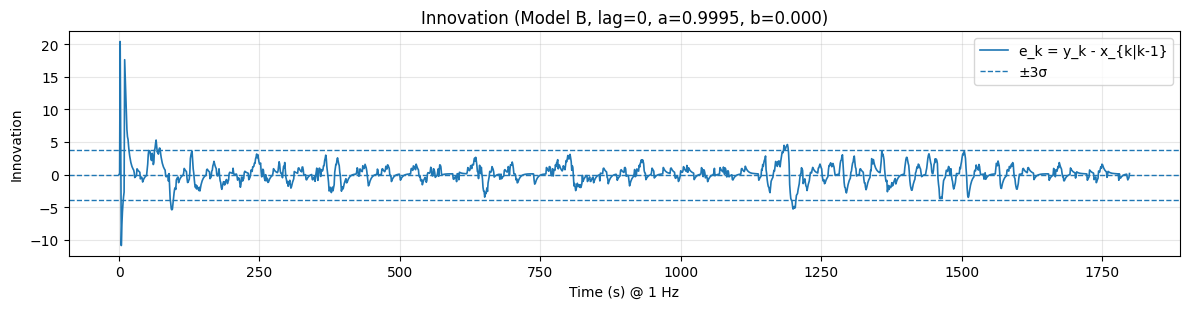

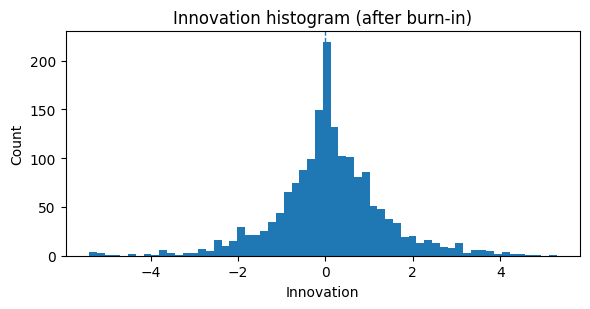

In [ ]:
def run_models_A_vs_B(hr_1hz, resp_1hz, tune=True, max_lag=10):
    y = np.asarray(hr_1hz, float)
    u = np.asarray(resp_1hz, float)
    T = min(len(y), len(u))
    y = y[:T]
    u = u[:T]

    # Model A 
    if tune:
        bestA_rmse, bestA = tune_modelA_ar1(y)
        aA, QA, RA = bestA["a"], bestA["Q"], bestA["R"]
    else:
        aA, QA, RA = 0.99, np.var(y)*1e-3, np.var(y)*0.2

    xA_f, xA_p, eA, *_ = kalman_ar1(y, a=aA, Q=QA, R=RA, P0=np.var(y))

    #Model B 
    if tune:
        bestB_rmse, bestB = tune_modelB_arx1(y, u, max_lag=max_lag)
        lagB, aB, bB, QB, RB = bestB["lag"], bestB["a"], bestB["b"], bestB["Q"], bestB["R"]
    else:
        lagB, aB, bB, QB, RB = 3, 0.99, 0.2, np.var(y)*1e-3, np.var(y)*0.2

    u_lag = shift_with_hold(u, lagB)
    xB_f, xB_p, eB, *_ = kalman_arx1(y, u_lag, a=aB, b=bB, Q=QB, R=RB, P0=np.var(y))

    out = {
        "rmse_pred_A": rmse(y[1:], xA_p[1:]),
        "rmse_filt_A": rmse(y[1:], xA_f[1:]),
        "rmse_pred_B": rmse(y[1:], xB_p[1:]),
        "rmse_filt_B": rmse(y[1:], xB_f[1:]),
        "paramsA": {"a": aA, "Q": QA, "R": RA},
        "paramsB": {"lag": lagB, "a": aB, "b": bB, "Q": QB, "R": RB},
    }

    print("=== Comparison ===")
    for k in ["rmse_pred_A","rmse_filt_A","rmse_pred_B","rmse_filt_B"]:
        print(k, ":", out[k])
    print("paramsA:", out["paramsA"])
    print("paramsB:", out["paramsB"])

    plot_state_fit(y, xA_p, xA_f, title=f"Model A (a={aA:.4f})")
    plot_innovation(eA, burn=30, title=f"Innovation (Model A, a={aA:.4f})")

    plot_modelB_with_input(y, u_lag, xB_p, xB_f, title=f"Model B (lag={lagB}, a={aB:.4f}, b={bB:.3f})")
    plot_innovation(eB, burn=30, title=f"Innovation (Model B, lag={lagB}, a={aB:.4f}, b={bB:.3f})")

    return out

# hr_1hz, resp_1hz = build_hr_and_resp_1hz(
#     root_dir="/opt/scratchspace/qli50/HSP",
#     cohort="I0004",
#     file_index=0,
#     minutes=30,
#     resp_col="ptaf",
# )
results = run_models_A_vs_B(hr_1hz, resp_1hz, tune=True, max_lag=10)



## Final results interpretation (Model A vs Model B)

### Summary of metrics
From the comparison output:

- **Model A (AR(1) Kalman)**
  - One-step prediction RMSE: $\mathrm{RMSE}_{\text{pred},A} \approx 1.25$
  - Filtered estimate RMSE: $\mathrm{RMSE}_{\text{filt},A} \approx 0.77$
  - Best-fit parameters: $a \approx 0.9995$, with process/measurement noise $(Q_A, R_A)$

- **Model B (ARX(1) Kalman with respiration input)**
  - One-step prediction RMSE: $\mathrm{RMSE}_{\text{pred},B} \approx 1.59$
  - Filtered estimate RMSE: $\mathrm{RMSE}_{\text{filt},B} \approx 1.23$
  - Best-fit parameters: $\text{lag}=0$, $a \approx 0.9995$, and **$b = 0.0$** (with $(Q_B, R_B)$)

### Which model performs better?
Model A performs better on both evaluation criteria:
$$
\mathrm{RMSE}_{\text{pred},A} < \mathrm{RMSE}_{\text{pred},B}
\quad\text{and}\quad
\mathrm{RMSE}_{\text{filt},A} < \mathrm{RMSE}_{\text{filt},B}.
$$
So, for this segment of data, the HR time series is explained well by a simple AR(1) latent dynamics model without needing an external input.

### What does $b=0$ and $\text{lag}=0$ mean?
In Model B, the state dynamics are:
$$
x_{k+1} = a\,x_k + b\,u_{k-\ell} + w_k,
$$
where $u_k$ is the (1 Hz) respiration driver and $\ell$ is a tested lag.

The tuning selected **$b=0.0$**, which means the best-performing ARX(1) model collapses to:
$$
x_{k+1} = a\,x_k + w_k,
$$
Essentially the same structure as Model A. The selected **$\ell=0$** indicates that, within the tested lags, there was no evidence that a delayed respiration effect improved prediction either.

### Interpretation in terms of the project goal (innovation as new information)
The innovation is:
$$
e_k = y_k - \hat{x}_{k\mid k-1}.
$$
A key project idea is: if the model is appropriate, the innovation should capture “new/unexplained” information (ideally behaving like approximately white noise after burn-in).

Our results suggest:
- Adding the respiration driver $u_k$ does **not** reduce the innovation magnitude or improve prediction error in this run (since Model B did worse and tuned to $b=0$).
- Therefore, **for this dataset window and this respiration feature**, respiration does not provide additional predictive information beyond HR’s own AR(1) structure.

### Bottom line
For the chosen preprocessing and the tested lag range, the data support the simpler conclusion:
> **Model A (AR(1) Kalman) is sufficient; the respiration input in Model B does not improve prediction and is effectively ignored ($b=0$).**
